# LFC and FDR Calculation

**Kexin Dong, Apr 12, 2026**

This notebook calculates guide-level log fold changes (LFCs), empirical p-values, combined p-values, and adjusted p-values from NGS guide count data, and appends sensor editing measurements from D5 and D15 for downstream calibration analyses.

# Improvements of this version
- Further packed functions to make it easier and clearer to run for multiple screens.
- Compatible with two baseline modes.
    -  **T0 baseline** (single input sample collected prior to mRNA electroporation)
    -  **Barcoding baseline** (per-condition, per-tissue median RPM across barcoding screen replicates)
    - mode is auto-detected by `run_screen_pipeline`.
- Added **concordant mean LFC** across replicates as an effect size estimate.
- Sensor editing percentages from all time points and conditions are attached to the output table.
- Added **z-scores** per replicate and per condition.
- Added **Stouffer's method** as an alternative to Fisher's method for combining replicate p-values.
- More detailed mathematical documentation throughout the notebook.

# How to use this notebook

**Step 1: Define functions.** Run all cells above this section (imports, `rpm`, `LFC_table_generator`, `attach_editing_info`, `bootstrap_null`, `plot_null_distributions`, `empirical_p_value`, `two_sided_FDR`, and `run_screen_pipeline`). These cells only define functions and do not produce output.

**Step 2: Load data.** Run the cells to load count tables, the library annotation file, and any other shared inputs.

**Step 3: Configure screens.** In the `screens` dictionary, add an entry for each screen you want to analyze. Each entry requires:
- `df_counts`: the raw count DataFrame (e.g. `ABE_OG_COUNTS`)
- `samps_to_merge`: replicate columns grouped by condition (list of lists)
- `new_names`: short condition names corresponding to each group
- `to_comparison_samps`: baseline sample column(s) for LFC calculation (e.g. `['input']`)
- `conditions_null`: which conditions to compute null distributions and FDR for
- `fp_editing`, `mle_names`, `mle_affix`: paths and labels for sensor editing CSVs

**Step 4: Run.** Execute the `screens` cell. The pipeline will run for every screen and print hit counts per condition. Results are stored in `results[screen_name]['LFC_FDR']`.

**Step 5: Save.** Run the final cell to export each screen's combined LFC+FDR table as a CSV.


# Output
For each screen, the final output table includes the following categories of information:

#### Effect Size

- **LFC** for each tissue and each replicate
- **Mean, concordant mean and median LFC** across replicates for each tissue
- **Mean, concordant mean and median z-score** across replicates for each tissue

#### Statistical Significance

- **Empirical p-value** for each tissue and each replicate, calculated using a non-parametric empirical null distribution
- **Combined p-value** across replicates for each tissue using both Fisher's method and Stouffer's method
- **FDR** for Fisher's combined p-value and Stouffer's combined p-value for each tissue

#### Sensor Editing

- **Target editing** and **correct editing** percentages at all time points for each condition

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os 
import functools
import upsetplot
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False
from matplotlib_venn import venn2
from sklearn.decomposition import PCA
import numpy as np
from scipy.stats import combine_pvalues
from statsmodels.stats.multitest import multipletests

yellows = sns.color_palette('Oranges').as_hex()
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
purples = sns.color_palette('Purples').as_hex()

## Overview and rationale

We initially analyzed guide abundance data using the widely used MAGeCK pipeline, which performs sequencing-depth normalization, calculates log2 fold-changes, and estimates p-values and FDR values for each guide relative to an input sample. However, in our screens, MAGeCK consistently appeared to overestimate the number of significant hits, often identifying a large fraction of guides as significantly enriched or depleted, including in noisy sample types such as meninges from the CBE screen.

We reasoned that this behavior may reflect a mismatch between the assumptions of MAGeCK and the structure of our dataset. MAGeCK was originally developed for CRISPR nuclease screens, where multiple guides typically target the same gene and can be aggregated into gene-level scores. In contrast, our analysis focuses on individual guide behavior, and replicate-level variability is important to preserve rather than collapse too early into a single summary statistic. We therefore adopted a more conservative, non-parametric approach that uses the observed behavior of control guides in the library, including safe-targeting and non-targeting guides, to define an empirical null distribution for each condition.



## Step 1: Normalize guide counts by sequencing depth

For each sample, raw guide counts were normalized by sequencing depth using **reads per million (RPM)**. A pseudocount of 1 was added to each guide count before normalization to avoid zero values and stabilize the downstream log transformation.

For guide *i* in sample *j*, RPM was calculated as:

$$
RPM_{ij} = \frac{count_{ij} + 1}{\sum_k (count_{kj} + 1)} \times 10^6
$$

where:

- $count_{ij}$ is the raw read count for guide *i* in sample *j*
- the denominator is the total pseudocount-adjusted read count across all guides in that sample

This normalization controls for differences in total sequencing depth across samples.

In [85]:
def rpm(df):
    df_rpm = df.copy()
    pseudocount = 1 
    samples = list(df.columns[2:])
    for k in samples:  
        col = np.asarray(df[k]) + pseudocount
        sum_col = np.sum(col)
        rpm = 1e6*(col/sum_col)
        df_rpm[k] = rpm
    return df_rpm

# usage: df_rpm = rpm(df)

## Step 2: Calculate guide-level log2 fold-change (LFC), summarize across replicates and calculate z-scores

For each guide in each replicate, the log2 fold-change was calculated by comparing the normalized abundance in the experimental sample to the median normalized abundance across "baseline" samples:

$$
LFC_{ij} = \log_2 \left( \frac{RPM_{ij,\mathrm{sample}}}{\widetilde{RPM}_{i,\mathrm{baseline}}} \right)
$$

where $RPM_{ij,\mathrm{sample}}$ is the normalized abundance of guide $i$ in replicate $j$, and $\widetilde{RPM}_{i,\mathrm{baseline}}$ is the **median** normalized abundance of guide $i$ across input samples. LFC values were retained separately for each replicate.

For each tissue, replicate-level LFC values were also **summarized** by calculating:

- **mean**
- **median**
- **concordant mean**: the arithmetic mean of LFC values from replicates whose direction of effect agreed with the majority direction. When using concordant mean, guides for which fewer than two-thirds of replicates agreed on the direction of effect were flagged as ambiguous and excluded from downstream hit calling.

To provide an additional standardized effect-size metric, LFC summary values were converted to z-scores.

$$
z_i = \frac{S_i - \mu_S}{\sigma_S}
$$

where:

- $S_i$ is the summary LFC of guide $i$ (concordant mean, mean, or median across replicates)
- $\mu_S$ is the mean of $S$ across all guides
- $\sigma_S$ is the standard deviation of $S$ across all guides


In [86]:
def LFC_table_generator(RPM_df, samp_dict, t0_comparison=['input_rep1', 'input_rep2', 'input_rep3'],
                        ambiguity_threshold=2/3,
                        baseline='t0',
                        RPM_df_bc=None, samp_dict_bc=None):
    """ 
    Function for generating LFC values
    RPM_df = dataframe containing RPM values (generated with pseudocount of +1)
    samp_dict = dictionary of samples and corresponding replicates
    t0_comparison = list containing base mean values for LFC calculation (used when baseline='t0')
    ambiguity_threshold = minimum fraction of replicates agreeing on direction for concordant mean (default: 2/3)
    baseline = 't0' (default) or 'barcoding'.
        't0': single global baseline = median of t0_comparison columns in RPM_df.
        'barcoding': per-condition baseline = median of matching barcoding replicates in RPM_df_bc.
            Requires RPM_df_bc (barcoding RPM dataframe) and samp_dict_bc (dict mapping
            condition -> list of barcoding replicate column names).
    """

    # global baseline (used only in 't0' mode)
    if baseline == 't0':
        t0_median = np.median(RPM_df[t0_comparison], axis=1)
    elif baseline == 'barcoding':
        if RPM_df_bc is None or samp_dict_bc is None:
            raise ValueError("baseline='barcoding' requires RPM_df_bc and samp_dict_bc")
    else:
        raise ValueError(f"baseline must be 't0' or 'barcoding', got {baseline!r}")

    df_holder = []
    for condition_of_interest in list(samp_dict.keys()):

        samp_of_interest = samp_dict[condition_of_interest]

        # determine per-condition baseline
        if baseline == 't0':
            cond_baseline = t0_median
        else:  # barcoding
            samp_of_interest_bc = samp_dict_bc[condition_of_interest]
            cond_baseline = np.median(RPM_df_bc[samp_of_interest_bc], axis=1)

        #calculate log2fc
        lfc_list = []
        for k in samp_of_interest:
            col = RPM_df[k]
            lfc = np.log2(col/cond_baseline)
            lfc_list.append(lfc)

        lfc_table = pd.DataFrame(dict(zip(samp_of_interest, lfc_list)))
        lfc_table[f'LFC_avg_{condition_of_interest}'] = np.average(lfc_table[samp_of_interest], axis=1)
        lfc_table[f'LFC_median_{condition_of_interest}'] = np.median(lfc_table[samp_of_interest], axis=1)

        # concordant mean: majority direction determined by sign vote across replicates
        rep_lfcs = lfc_table[samp_of_interest].values  # (n_guides, n_reps)
        n_reps = len(samp_of_interest)
        signs = np.sign(rep_lfcs)  # -1, 0, or 1

        n_positive = np.sum(signs > 0, axis=1)  # number of replicates with positive LFC
        n_negative = np.sum(signs < 0, axis=1)  # number of replicates with negative LFC
        majority_positive = n_positive >= n_negative  # True = majority direction is positive

        agrees = np.where(majority_positive[:, np.newaxis], signs >= 0, signs <= 0)

        frac_concordant = np.sum(agrees, axis=1) / n_reps
        is_directional = frac_concordant >= ambiguity_threshold  # True = concordant, False = ambiguous

        rep_lfcs_concordant = np.where(agrees, rep_lfcs, np.nan)
        concordant_mean = np.nanmean(rep_lfcs_concordant, axis=1)
        concordant_mean[~is_directional] = np.nan

        lfc_table[f'LFC_concordant_mean_{condition_of_interest}'] = concordant_mean
        lfc_table[f'LFC_directional_{condition_of_interest}'] = is_directional

        # z-scores for each summary metric: z = (S - mean(S)) / std(S)
        for summary in ['avg', 'median', 'concordant_mean']:
            col = lfc_table[f'LFC_{summary}_{condition_of_interest}']
            avg = np.average(col[~np.isnan(col)])
            std = np.std(col[~np.isnan(col)])
            lfc_table[f'z_score_{summary}_{condition_of_interest}'] = (col - avg) / std

        lfc_table['Input_median'] = cond_baseline
        ids = RPM_df[['sgRNA', 'gene']]

        LFC_df = pd.concat((ids, lfc_table), axis=1)
        df_holder.append(LFC_df)

    #and combine different tissues into same table
    combined_LFC = pd.concat(df_holder, axis=1)
    combined_LFC= combined_LFC.loc[:,~combined_LFC.columns.duplicated()].copy()
    combined_LFC = combined_LFC.rename(columns = {'sgRNA':'gRNA_id', 'gene':'Gene'})

    return combined_LFC

## Step 3: Add editing efficiency information to the LFC output dataframe

In [87]:
def attach_editing_info(LFC_df, fp_editing, mle_names, mle_affix, valid_grnas):
    """
    Merge sensor editing measurements into an LFC table.
    
    LFC_df = LFC dataframe with 'gRNA_id' column
    fp_editing = path to folder containing MLE editing CSVs
    mle_names = list of condition names (e.g. ['input', 'd5', 'd15', 'bm', 'spleen', 'men'])
    mle_affix = file name suffix (e.g. 'ABE_MLE'); use '' for no suffix
    valid_grnas = array-like of valid guide IDs to keep (e.g. df_counts['sgRNA'])
    """
    LFC = LFC_df.copy()
    for condition in mle_names:
        fname = f'{condition}_{mle_affix}.csv' if mle_affix else f'{condition}.csv'
        editing = pd.read_csv(os.path.join(fp_editing, fname))
        editing = editing[['Guide_ID', 'Reads_aligned_all_amplicons', 'corr_perc',
                           'target_base_edit_perc', 'byproduct_INDEL_perc', 'byproduct_sub_perc']].rename(
            columns={'Guide_ID': 'gRNA_id',
                     'Reads_aligned_all_amplicons': f'sensor_reads_{condition}',
                     'corr_perc': f'corr_perc_{condition}',
                     'target_base_edit_perc': f'target_base_edit_perc_{condition}',
                     'byproduct_INDEL_perc': f'byproduct_INDEL_perc_{condition}',
                     'byproduct_sub_perc': f'byproduct_sub_perc_{condition}'}
        )
        editing = editing[editing['gRNA_id'].isin(valid_grnas)]
        LFC = pd.merge(LFC, editing, on='gRNA_id')
    return LFC

# usage:
# LFC = attach_editing_info(LFC, fp_editing='MLE/focused/ABE_BC', 
#                           mle_names=['input','d5','d15','bm','spleen','men'],
#                           mle_affix='ABE_MLE', valid_grnas=df_counts['sgRNA'])

## Step 4: Construct an empirical null distribution using control guides

To estimate statistical significance without imposing a parametric distribution, we constructed an empirical null distribution of LFC values for each tissue and screen using control guides.

Specifically, for each tissue within each screen:

1. We identified control guides in the library, including safe-targeting and non-targeting guides.
2. We calculated the LFC of each control guide in each replicate relative to the corresponding input sample.
3. We pooled the control-guide LFC values across replicates within the same tissue.

This pooled distribution reflects the behavior expected under a null model in which guides do not have strong biological enrichment or depletion effects, while still capturing tissue-specific technical and biological variability.

Because the number of control-guide observations was not always sufficient to provide a smooth null for p-value estimation, we expanded the null distribution by **bootstrap resampling with replacement**. For each tissue in each screen, we sampled 10,000 LFC values from the pooled control-guide LFCs to generate the final empirical null distribution.

Separate empirical null distributions were generated for each condition, including:

- in vitro
- spleen
- bone marrow
- meninges

and separately for each screen:

- ABE screen
- CBE screen


In [88]:
def bootstrap_null(LFC_df, conditions, samp_dict, control_classes,
                   n_bootstrap=10000, seed=0):
    """
    Build empirical null distributions by bootstrap-resampling control guide LFCs.

    Parameters
    ----------
    LFC_df : pd.DataFrame
        LFC table (output of LFC_table_generator) with a 'classification' column.
    conditions : list of str
        Conditions to build nulls for (e.g. ['bm', 'spleen', 'men']).
    samp_dict : dict
        {condition: [replicate_columns]}.
    control_classes : list of str
        Classification labels for control guides (e.g. ['non-targeting control', 'safe-targeting control']).
    n_bootstrap : int
        Number of bootstrap samples (default 10000).
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    null_dict : dict
        {condition: np.array of bootstrapped LFC values}.
    controls : pd.DataFrame
        Subset of LFC_df containing only control guides.
    """
    np.random.seed(seed)
    controls = LFC_df[LFC_df['classification'].isin(control_classes)].reset_index(drop=True)
    null_dict = {}
    for condition in conditions:
        samp_of_interest = samp_dict[condition]
        nt_gRNA_values = controls[samp_of_interest].to_numpy().flatten()
        print(f'{condition}: {len(nt_gRNA_values)} control guide LFC values '
              f'({len(nt_gRNA_values)//len(samp_of_interest)} guides x {len(samp_of_interest)} replicates)')
        null_dict[condition] = np.random.choice(nt_gRNA_values, size=n_bootstrap, replace=True)
    return null_dict, controls


def plot_null_distributions(null_dict, controls, samp_dict, bins=np.linspace(-11, 8, 80),
                            name_dict=None, color='tab:purple', save_path=None):
    """
    Visualize bootstrapped null distributions with per-replicate overlays.

    Parameters
    ----------
    null_dict : dict
        {condition: bootstrapped LFC array} (output of bootstrap_null).
    controls : pd.DataFrame
        Control guide LFC table (output of bootstrap_null).
    samp_dict : dict
        {condition: [replicate_columns]}.
    bins : array-like
        Histogram bin edges.
    name_dict : dict or None
        {condition: display_title}. Defaults to condition name.
    color : str
        Color for the bootstrapped null histogram (default: 'tab:purple').
    save_path : str or None
        If provided, save figure to this path (e.g. 'figures/null_dist.pdf').
    """
    conditions = list(null_dict.keys())
    n = len(conditions)
    if name_dict is None:
        name_dict = {c: c for c in conditions}

    fig, ax = plt.subplots(1, n, figsize=(3.5 * n, 3.5), sharex=True, sharey=False)
    if n == 1:
        ax = [ax]

    for idx, condition in enumerate(conditions):
        ax[idx].hist(null_dict[condition], density=True, bins=bins, alpha=.7,
                     color=color, label='Bootstrapped Null')
        for idx2, k in enumerate(samp_dict[condition]):
            label = 'Replicates' if idx2 == 0 else None
            ax[idx].hist(controls[k], density=True, bins=bins, alpha=.2, linewidth=.5,
                         color='black', histtype='step', label=label)
        ax[idx].set_title(name_dict[condition], fontsize=15)
        ax[idx].spines[['top', 'right']].set_visible(False)
        ax[idx].tick_params(axis='both', which='major', labelsize=12)
        ax[idx].legend(fontsize=8, loc='upper left')

    ax[0].set_ylabel('Density', fontsize=14)
    ax[n // 2].set_xlabel('LFC', fontsize=14)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Figure saved to {save_path}')

    plt.show()


## Step 5: Calculate empirical p-values for each guide in each replicate

For each guide in each replicate, the observed LFC was compared against the corresponding tissue-specific empirical null distribution. Two one-sided tail probabilities were computed:

$$
p_{\mathrm{high}} = \frac{1 + \#(null \geq LFC_{\mathrm{obs}})}{1 + N_{\mathrm{null}}}
\qquad
p_{\mathrm{low}} = \frac{1 + \#(null \leq LFC_{\mathrm{obs}})}{1 + N_{\mathrm{null}}}
$$

where $N_{\mathrm{null}}$ is the size of the bootstrapped null distribution. A pseudocount of 1 was added to both numerator and denominator to avoid zero p-values. These two tail probabilities were retained separately for downstream combination, so that enrichment and depletion could be assessed independently.

---

## Step 6: Combine replicate-level p-values and correct for multiple testing

Replicate-level empirical p-values were combined within each tissue using `scipy.stats.combine_pvalues()`. We applied two complementary combination methods:

- **Fisher's method**, which sums log-transformed p-values across replicates. Fisher's method is sensitive to strong signal in individual replicates: even if only one replicate shows a very small p-value while others are non-significant, the combined result may still be significant.

- **Stouffer's method**, which converts p-values to z-scores and averages them. Stouffer's method requires more consistent evidence across replicates and is less influenced by a single extreme value.

In this study, we report results based on **Fisher's method** for consistency with common practices in the field. Combined p-values from both methods are documented in the supplemental data.

It is important to note that both methods assume independence between tests. In our experimental setting, this assumption is not strictly satisfied, as biological replicates share the same initial guide pool and may therefore exhibit correlated variability.

Combined p-values were then adjusted for multiple hypothesis testing using the **Benjamini-Hochberg** procedure (`statsmodels.stats.multitest.multipletests()`), applied separately within each tissue and for each combination method. The final two-sided FDR for each guide was defined as:

$$
FDR = \min(FDR_{\mathrm{high}},\ FDR_{\mathrm{low}})
$$

Unless otherwise noted, guides were considered significant at $FDR < 0.1$.


In [89]:
# Function to compute empirical p-values
def empirical_p_value(observed, null_distribution):
    S_high = sum(null_distribution >= observed)
    S_low = sum(null_distribution <= observed)
    N = len(null_distribution)

    # Compute two-sided p-value
    p_high = (S_high + 1) / (N + 1)
    p_low = (S_low + 1) / (N + 1)
    return p_high, p_low

def two_sided_FDR(condition_of_interest, samp_of_interest, LFC_df, null_dict):
    ''' 
    condition_of_interest = name of condition (e.g. "spleen")
    samp_of_interest = list of all replicates ["spleen1", "spleen2", "spleen3"]
    LFC_df = dataframe with LFC values
    null_dict = dictionary containing bootstrapped null distributions for each tissue & editor combination
    '''

    # Load the null distribution
    nt_gRNA_values = null_dict[condition_of_interest]

    # Targeting gRNAs (including NT for completeness)
    gRNA_values = np.asarray(LFC_df[samp_of_interest])

    # Compute p-values for each replicate separately (two-tailed)
    p_values_high = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[0] for rep in gRNA] 
        for gRNA in gRNA_values
    ])
    p_values_low = np.array([
        [empirical_p_value(rep, nt_gRNA_values)[1] for rep in gRNA] 
        for gRNA in gRNA_values
    ])

    # Combine p-values across replicates using Fisher's method
    combined_p_values_high = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_high
    ])
    combined_p_values_low = np.array([
        combine_pvalues(p_vals, method='fisher')[1] for p_vals in p_values_low
    ])

    combined_p_values_high_stouffers = np.array([
        combine_pvalues(p_vals, method='stouffer')[1] for p_vals in p_values_high
    ])
    combined_p_values_low_stouffers = np.array([
        combine_pvalues(p_vals, method='stouffer')[1] for p_vals in p_values_low
    ])

    # Adjust for multiple testing (Benjamini-Hochberg FDR)
    adjusted_p_values_high = multipletests(combined_p_values_high, method='fdr_bh')[1]
    adjusted_p_values_low = multipletests(combined_p_values_low, method='fdr_bh')[1]

    adjusted_p_values_high_stouffers = multipletests(combined_p_values_high_stouffers, method='fdr_bh')[1]
    adjusted_p_values_low_stouffers = multipletests(combined_p_values_low_stouffers, method='fdr_bh')[1]

    # Store results in the dataframe
    LFC_df[f'p_high_unadjusted_{condition_of_interest}_fishers'] = combined_p_values_high
    LFC_df[f'p_low_unadjusted_{condition_of_interest}_fishers'] = combined_p_values_low
    LFC_df[f'FDR_high_{condition_of_interest}_fishers'] = adjusted_p_values_high
    LFC_df[f'FDR_low_{condition_of_interest}_fishers'] = adjusted_p_values_low

    LFC_df[f'p_high_unadjusted_{condition_of_interest}_stouffers'] = combined_p_values_high_stouffers
    LFC_df[f'p_low_unadjusted_{condition_of_interest}_stouffers'] = combined_p_values_low_stouffers
    LFC_df[f'FDR_high_{condition_of_interest}_stouffers'] = adjusted_p_values_high_stouffers
    LFC_df[f'FDR_low_{condition_of_interest}_stouffers'] = adjusted_p_values_low_stouffers

    #Combine low and high FDRs for ease of manipulation and plotting
    min_FDR = []
    for _, val in LFC_df.iterrows():
        FDR_low = val[f'FDR_low_{condition_of_interest}_fishers']
        FDR_high = val[f'FDR_high_{condition_of_interest}_fishers']
        min_FDR.append(min(FDR_low, FDR_high))

    LFC_df[f'FDR_{condition_of_interest}_fishers'] = min_FDR

    min_FDR = []
    for _, val in LFC_df.iterrows():
        FDR_low = val[f'FDR_low_{condition_of_interest}_stouffers']
        FDR_high = val[f'FDR_high_{condition_of_interest}_stouffers']
        min_FDR.append(min(FDR_low, FDR_high))

    LFC_df[f'FDR_{condition_of_interest}_stouffers'] = min_FDR

    return LFC_df

## MAIN FUNCTION

In [90]:
def run_screen_pipeline(screen_name, df_counts, library, samps_to_merge, new_names,
                        conditions_null,
                        fp_editing, mle_names, mle_affix,
                        to_comparison_samps=None,
                        df_counts_bc=None, samps_to_merge_bc=None, new_names_bc=None,
                        control_classes=['non-targeting control', 'safe-targeting control'],
                        ambiguity_threshold=2/3, n_bootstrap=10000, seed=0,
                        null_color='tab:purple'):
    """
    Run the full LFC → null → FDR pipeline for a single screen.

    Parameters
    ----------
    screen_name : str
        Label for this screen (e.g. 'ABE_OG'), used in print statements.
    df_counts : pd.DataFrame
        Raw count table for this screen (EPO / real screen).
    library : pd.DataFrame
        Library annotation table with 'gRNA_id' and 'classification' columns.
    samps_to_merge : list of list of str
        Replicate columns grouped by condition.
    new_names : list of str
        Condition names corresponding to samps_to_merge.
    conditions_null : list of str
        Conditions to compute null distributions and FDR for.
    fp_editing : str
        Path to folder containing MLE editing CSVs.
    mle_names : list of str
        Condition names for editing data.
    mle_affix : str
        File name suffix for editing CSVs.
    to_comparison_samps : list of str, optional
        Baseline sample columns for t0-mode LFC calculation.
        Required when df_counts_bc is None (t0 mode).
    df_counts_bc : pd.DataFrame, optional
        Raw count table for barcoding screen. If provided, baseline='barcoding'.
    samps_to_merge_bc : list of list of str, optional
        Replicate columns grouped by condition for the barcoding screen.
        Required when df_counts_bc is provided.
    new_names_bc : list of str, optional
        Condition names for samps_to_merge_bc. Required when df_counts_bc is provided.
    control_classes : list of str
        Classification labels for control guides.
    ambiguity_threshold : float
        Threshold for concordant mean (default 2/3).
    n_bootstrap : int
        Number of bootstrap samples (default 10000).
    seed : int
        Random seed.
    null_color : str
        Color for the null distribution histogram (default: 'tab:purple').

    Returns
    -------
    combined_LFC_FDR : pd.DataFrame
        Final table with LFC, z-scores, editing info, p-values, and FDR.
    null_dict : dict
        Bootstrapped null distributions.
    controls : pd.DataFrame
        Control guide subset.
    """
    print(f'===== {screen_name} =====')

    # Determine baseline mode
    if df_counts_bc is not None:
        if samps_to_merge_bc is None or new_names_bc is None:
            raise ValueError("df_counts_bc provided but samps_to_merge_bc or new_names_bc is missing")
        baseline = 'barcoding'
    else:
        if to_comparison_samps is None:
            raise ValueError("to_comparison_samps is required when not using barcoding baseline")
        baseline = 't0'

    # Step 1: RPM normalization
    df_rpm = rpm(df_counts)
    samp_dict = dict(zip(new_names, samps_to_merge))

    # Step 2: LFC table generation
    if baseline == 'barcoding':
        df_rpm_bc = rpm(df_counts_bc)
        samp_dict_bc = dict(zip(new_names_bc, samps_to_merge_bc))
        LFC = LFC_table_generator(df_rpm, samp_dict,
                                   ambiguity_threshold=ambiguity_threshold,
                                   baseline='barcoding',
                                   RPM_df_bc=df_rpm_bc, samp_dict_bc=samp_dict_bc)
    else:
        LFC = LFC_table_generator(df_rpm, samp_dict, t0_comparison=to_comparison_samps,
                                   ambiguity_threshold=ambiguity_threshold)

    # Step 3: Attach library and editing information
    LFC = pd.merge(LFC, library, on='gRNA_id')
    LFC = attach_editing_info(LFC, fp_editing=fp_editing,
                              mle_names=mle_names, mle_affix=mle_affix,
                              valid_grnas=df_counts['sgRNA'])

    # Step 4: Bootstrap null distribution
    null_dict, controls = bootstrap_null(LFC, conditions_null, samp_dict,
                                         control_classes=control_classes,
                                         n_bootstrap=n_bootstrap, seed=seed)

    # Visualize null distributions
    plot_null_distributions(null_dict, controls, samp_dict, color=null_color)

    # Steps 5-6: Empirical p-values, combined p-values, and FDR
    df_holder = []
    for condition in conditions_null:
        samp_of_interest = samp_dict[condition]
        LFC_df = two_sided_FDR(condition, samp_of_interest, LFC, null_dict)
        df_holder.append(LFC_df)

    combined_LFC_FDR = pd.concat(df_holder, axis=1)
    combined_LFC_FDR = combined_LFC_FDR.loc[:,~combined_LFC_FDR.columns.duplicated()].copy()

    n_total = len(combined_LFC_FDR)
    for condition in conditions_null:
        fisher_mask = combined_LFC_FDR[f'FDR_{condition}_fishers'] < 0.1
        stouffer_mask = combined_LFC_FDR[f'FDR_{condition}_stouffers'] < 0.1
        overlap_mask = fisher_mask & stouffer_mask

        n_fisher = fisher_mask.sum()
        n_stouffer = stouffer_mask.sum()
        n_overlap = overlap_mask.sum()
        print(f'  {condition} (n={n_total}): {n_fisher} Fisher hits, {n_stouffer} Stouffer hits, {n_overlap} overlap (FDR<0.1)')

        for method, mask in [('Fisher', fisher_mask), ('Stouffer', stouffer_mask)]:
            hits = combined_LFC_FDR[mask]
            for lfc_col, threshold in [
                (f'LFC_avg_{condition}', 1),
                (f'LFC_median_{condition}', 1),
                (f'LFC_concordant_mean_{condition}', 1),
            ]:
                if lfc_col not in hits.columns:
                    continue
                n_dep = (hits[lfc_col] < -threshold).sum()
                n_enr = (hits[lfc_col] > threshold).sum()
                print(f'    [{method}] |{lfc_col}|>1: {n_dep} depleted (<-1), {n_enr} enriched (>1)')

        lfc_avg_col = f'LFC_avg_{condition}'
        if lfc_avg_col in combined_LFC_FDR.columns:
            overlap_hits = combined_LFC_FDR[overlap_mask]
            n_ol_dep = (overlap_hits[lfc_avg_col] < -1).sum()
            n_ol_enr = (overlap_hits[lfc_avg_col] > 1).sum()
            print(f'    [Overlap] |LFC_avg|>1: {n_ol_dep} depleted (<-1), {n_ol_enr} enriched (>1)')

    return combined_LFC_FDR, null_dict, controls

## Run the samples

In [91]:
fp = 'counts/focused'
ABE_BC_COUNTS = pd.read_csv(fp + '/FC_ABE_BC_COUNTS.txt', sep='\t')
CBE_BC_COUNTS = pd.read_csv(fp + '/FC_CBE_BC_COUNTS_new.txt', sep='\t')
ABE_EPO_COUNTS = pd.read_csv(fp + '/FC_ABE_EPO_COUNTS.txt', sep='\t')
CBE_EPO_COUNTS = pd.read_csv(fp + '/FC_CBE_EPO_COUNTS_new.txt', sep='\t')
fp = 'counts/og'
ABE_OG_COUNTS = pd.read_csv(fp + '/OG_ABE_COUNTS.txt', sep='\t')
CBE_OG_COUNTS = pd.read_csv(fp + '/OG_CBE_COUNTS.txt', sep='\t')
#also add in information about the edits of interest
LIB_ORI = pd.read_csv('MBESv2_CORRECTED.csv')[['gRNA_id', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m']]
LIB_FOCUSED = pd.read_csv('MBESv2_focused.csv')[['gRNA_id', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m']]

In [92]:
ABE_OG_samps_to_merge = [['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                        ['d15_rep1','d15_rep2','d15_rep3'],
                        ['d5_rep1','d5_rep2','d5_rep3'], 
                        ['plasmidlib'],
                        ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                        ['spleen1','spleen2','spleen3','spleen4']]

ABE_OG_new_names = ['bm', 'd15', 'd5', 'lib', 'men', 'spleen']

CBE_OG_samps_to_merge = [['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5','bonemarrow6','bonemarrow7','bonemarrow8','bonemarrow9','bonemarrow10'],
                        ['d15_rep1','d15_rep2','d15_rep3'],
                        ['d5_rep1','d5_rep2','d5_rep3'],
                        ['plasmidlib'],
                        ['meninges1','meninges2','meninges3','meninges4','meninges5','meninges6','meninges7','meninges8','meninges9','meninges10',],
                        ['spleen1','spleen2','spleen3','spleen4','spleen5','spleen6','spleen7','spleen8','spleen9']]  # spleen10 excluded (abnormal skewing)

CBE_OG_new_names = ['bm', 'd15', 'd5', 'lib', 'men', 'spleen']

# ABE EPO: no sample exclusions
ABE_EPO_samps_to_merge = [['bm1', 'bm3', 'bm4', 'bm5'],  # bm2 excluded (abnormal skewing)
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5'],
['input'],
['lib'],
# ['men1', 'men2', 'men3','men4', 'men5'], 
['spleen1', 'spleen3', 'spleen4', 'spleen5']]  # spleen2 excluded (abnormal skewing)

# ABE BC: bm2, spleen2 excluded (abnormal skewing)
ABE_BC_samps_to_merge = [['bm1', 'bm3', 'bm4', 'bm5'],  # bm2 excluded (abnormal skewing)
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5'],
['input'],
['lib'],
# ['men1', 'men2', 'men3','men4', 'men5'], 
['spleen1', 'spleen3', 'spleen4', 'spleen5']]  # spleen2 excluded (abnormal skewing)

ABE_FC_new_names = ['bm', 'd15', 'd5','input','lib','spleen']

# CBE EPO: bm2,5,8 and spleen2,5,8 excluded previously; d15-rep2 newly excluded (abnormal skewing)
CBE_EPO_samps_to_merge = [['bm1', 'bm3', 'bm4','bm6','bm7','bm9','bm10'],  # bm2,5,8 excluded
['d15-rep1', 'd15-rep3','d15-rep4', 'd15-rep5'],  # d15-rep2 excluded (abnormal skewing)
['d5'],
['input'],
['lib'], 
['spleen1',  'spleen3', 'spleen4',  'spleen6', 'spleen7',  'spleen9', 'spleen10']]  # spleen2,5,8 excluded

# CBE BC: bm2,6,10 and spleen2,6,10 excluded previously; bm1,8 and spleen1,8 newly excluded (abnormal skewing)
CBE_BC_samps_to_merge = [['bm3', 'bm4', 'bm5','bm7','bm9'],  # bm1,2,6,8,10 excluded
['d15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5'], 
['d5'],
['input'],
['lib'], 
['spleen3', 'spleen4', 'spleen5',  'spleen7', 'spleen9']]  # spleen1,2,6,8,10 excluded

CBE_FC_new_names = ['bm', 'd15', 'd5','input','lib', 'spleen']


In [93]:
### configure screens here --- add more screens as needed by following the template!
screens = {
    # --- Focused Screens ---
    'ABE_FC_EPO_T0': dict(
        df_counts=ABE_EPO_COUNTS,
        library=LIB_FOCUSED,
        samps_to_merge=ABE_EPO_samps_to_merge,
        new_names=ABE_FC_new_names,
        to_comparison_samps=['input'],
        conditions_null=['d5', 'd15', 'spleen', 'bm'],
        fp_editing='MLE/focused/ABE_EPO',
        mle_names=['input','d5','d15','bm','spleen'],
        mle_affix='',
        null_color='tab:purple'
    ),

    'CBE_FC_EPO_T0': dict(
        df_counts=CBE_EPO_COUNTS,
        library=LIB_FOCUSED,
        samps_to_merge=CBE_EPO_samps_to_merge,
        new_names=CBE_FC_new_names,
        to_comparison_samps=['input'],
        conditions_null=['d5', 'd15', 'spleen', 'bm'],
        fp_editing='MLE/focused/CBE_EPO_NEW',
        mle_names=['input','d5','d15','bm','spleen'],
        mle_affix='',
        null_color='tab:blue'
    ),

    'ABE_FC_BC_T0': dict(
        df_counts=ABE_BC_COUNTS,
        library=LIB_FOCUSED,
        samps_to_merge=ABE_BC_samps_to_merge,
        new_names=ABE_FC_new_names,
        to_comparison_samps=['input'],
        conditions_null=['d5', 'd15', 'spleen', 'bm'],
        fp_editing='MLE/focused/ABE_EPO',
        mle_names=['input','d5','d15','bm','spleen'],
        mle_affix='',
        null_color='tab:purple'
    ),

    'CBE_FC_BC_T0': dict(
        df_counts=CBE_BC_COUNTS,
        library=LIB_FOCUSED,
        samps_to_merge=CBE_BC_samps_to_merge,
        new_names=CBE_FC_new_names,
        to_comparison_samps=['input'],
        conditions_null=['d5', 'd15', 'spleen', 'bm'],
        fp_editing='MLE/focused/CBE_EPO_NEW',
        mle_names=['input','d5','d15','bm','spleen'],
        mle_affix='',
        null_color='tab:blue'
    ),


    # barcoding analysis
    'ABE_FC_EPO_TO_BC': dict(
        df_counts=ABE_EPO_COUNTS,
        df_counts_bc=ABE_BC_COUNTS,
        library=LIB_FOCUSED,
        samps_to_merge=ABE_EPO_samps_to_merge,
        new_names=ABE_FC_new_names,
        samps_to_merge_bc=ABE_BC_samps_to_merge,
        new_names_bc=ABE_FC_new_names,
        conditions_null=['d5', 'd15', 'spleen', 'bm'],
        fp_editing='MLE/focused/ABE_EPO',
        mle_names=['input','d5','d15','bm','spleen'],
        mle_affix='',
        null_color='tab:purple'
    ),

    'CBE_FC_EPO_TO_BC': dict(
        df_counts=CBE_EPO_COUNTS,
        df_counts_bc=CBE_BC_COUNTS,
        library=LIB_FOCUSED,
        samps_to_merge=CBE_EPO_samps_to_merge,
        new_names=CBE_FC_new_names,
        samps_to_merge_bc=CBE_BC_samps_to_merge,
        new_names_bc = CBE_FC_new_names,
        conditions_null=['d5', 'd15', 'spleen', 'bm'],
        fp_editing='MLE/focused/CBE_EPO_NEW',
        mle_names=['input','d5','d15','bm','spleen'],
        mle_affix='',
        null_color='tab:blue'
    ),

    # # --- OG screens ---
    # 'ABE_OG': dict(
    #     df_counts=ABE_OG_COUNTS,
    #     library=LIB_ORI,
    #     samps_to_merge=ABE_OG_samps_to_merge,
    #     new_names=ABE_OG_new_names,
    #     to_comparison_samps=['input_rep1', 'input_rep2', 'input_rep3'],
    #     conditions_null=['d5', 'd15', 'spleen', 'bm', 'men'],
    #     fp_editing='MLE/og/ABE',
    #     mle_names=['input', 'd5', 'd15', 'bm', 'spleen', 'men'],
    #     mle_affix='ABE_MLE',
    #     null_color='tab:purple'
    # ),
    
    # 'CBE_OG': dict(
    #     df_counts=CBE_OG_COUNTS,
    #     library=LIB_ORI,
    #     samps_to_merge=CBE_OG_samps_to_merge,
    #     new_names=CBE_OG_new_names,
    #     to_comparison_samps=['input_rep1', 'input_rep2', 'input_rep3'],
    #     conditions_null=['d5', 'd15', 'spleen', 'bm', 'men'],
    #     fp_editing='MLE/og/CBE',
    #     mle_names=['input', 'd5', 'd15', 'bm', 'spleen', 'men'],
    #     mle_affix='CBE_MLE',
    #     null_color='tab:blue'
    # ),
}

===== ABE_FC_EPO_T0 =====
d5: 206 control guide LFC values (206 guides x 1 replicates)
d15: 1030 control guide LFC values (206 guides x 5 replicates)
spleen: 824 control guide LFC values (206 guides x 4 replicates)
bm: 824 control guide LFC values (206 guides x 4 replicates)


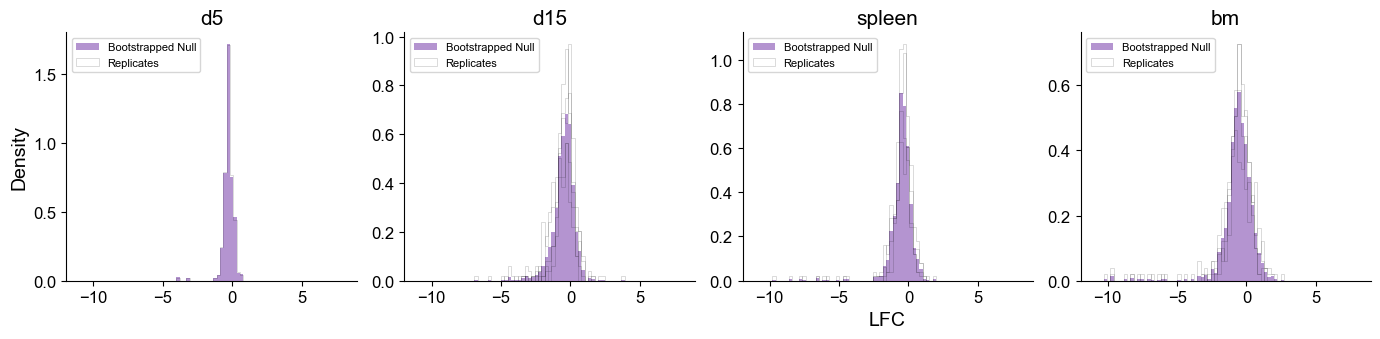

  d5 (n=376): 121 Fisher hits, 121 Stouffer hits, 121 overlap (FDR<0.1)
    [Fisher] |LFC_avg_d5|>1: 0 depleted (<-1), 22 enriched (>1)
    [Fisher] |LFC_median_d5|>1: 0 depleted (<-1), 22 enriched (>1)
    [Fisher] |LFC_concordant_mean_d5|>1: 0 depleted (<-1), 22 enriched (>1)
    [Stouffer] |LFC_avg_d5|>1: 0 depleted (<-1), 22 enriched (>1)
    [Stouffer] |LFC_median_d5|>1: 0 depleted (<-1), 22 enriched (>1)
    [Stouffer] |LFC_concordant_mean_d5|>1: 0 depleted (<-1), 22 enriched (>1)
    [Overlap] |LFC_avg|>1: 0 depleted (<-1), 22 enriched (>1)
  d15 (n=376): 151 Fisher hits, 174 Stouffer hits, 150 overlap (FDR<0.1)
    [Fisher] |LFC_avg_d15|>1: 10 depleted (<-1), 31 enriched (>1)
    [Fisher] |LFC_median_d15|>1: 10 depleted (<-1), 35 enriched (>1)
    [Fisher] |LFC_concordant_mean_d15|>1: 10 depleted (<-1), 32 enriched (>1)
    [Stouffer] |LFC_avg_d15|>1: 12 depleted (<-1), 31 enriched (>1)
    [Stouffer] |LFC_median_d15|>1: 12 depleted (<-1), 35 enriched (>1)
    [Stouffer] |LFC_c

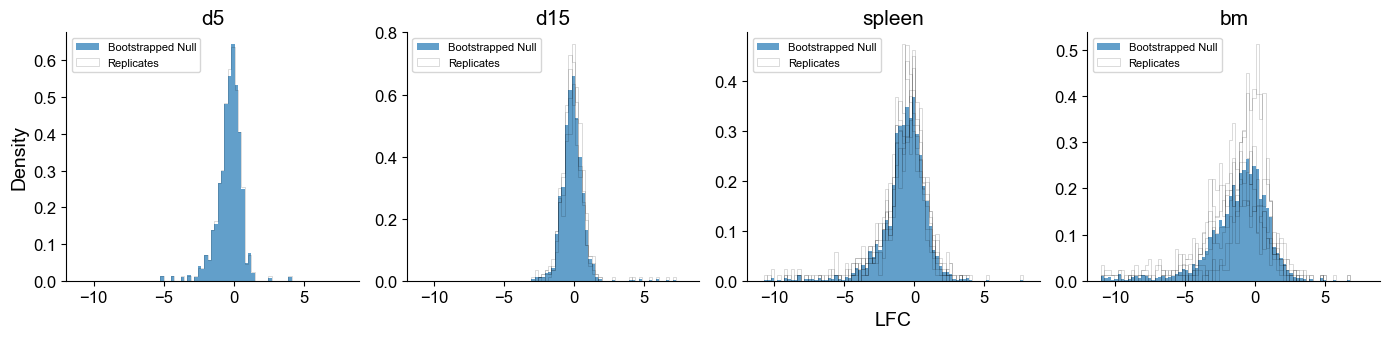

  d5 (n=1257): 11 Fisher hits, 11 Stouffer hits, 11 overlap (FDR<0.1)
    [Fisher] |LFC_avg_d5|>1: 9 depleted (<-1), 2 enriched (>1)
    [Fisher] |LFC_median_d5|>1: 9 depleted (<-1), 2 enriched (>1)
    [Fisher] |LFC_concordant_mean_d5|>1: 9 depleted (<-1), 2 enriched (>1)
    [Stouffer] |LFC_avg_d5|>1: 9 depleted (<-1), 2 enriched (>1)
    [Stouffer] |LFC_median_d5|>1: 9 depleted (<-1), 2 enriched (>1)
    [Stouffer] |LFC_concordant_mean_d5|>1: 9 depleted (<-1), 2 enriched (>1)
    [Overlap] |LFC_avg|>1: 9 depleted (<-1), 2 enriched (>1)
  d15 (n=1257): 140 Fisher hits, 234 Stouffer hits, 132 overlap (FDR<0.1)
    [Fisher] |LFC_avg_d15|>1: 37 depleted (<-1), 56 enriched (>1)
    [Fisher] |LFC_median_d15|>1: 36 depleted (<-1), 66 enriched (>1)
    [Fisher] |LFC_concordant_mean_d15|>1: 36 depleted (<-1), 65 enriched (>1)
    [Stouffer] |LFC_avg_d15|>1: 55 depleted (<-1), 56 enriched (>1)
    [Stouffer] |LFC_median_d15|>1: 53 depleted (<-1), 64 enriched (>1)
    [Stouffer] |LFC_concordan

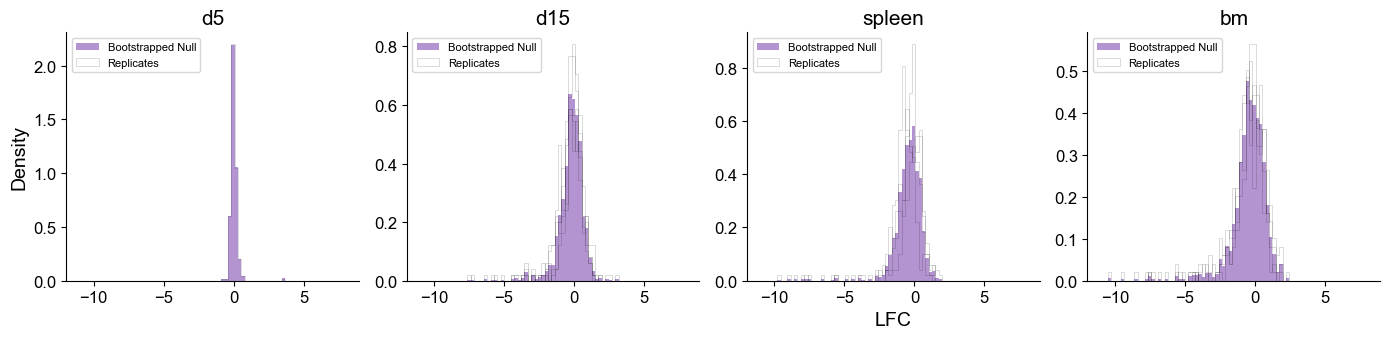

  d5 (n=376): 0 Fisher hits, 0 Stouffer hits, 0 overlap (FDR<0.1)
    [Fisher] |LFC_avg_d5|>1: 0 depleted (<-1), 0 enriched (>1)
    [Fisher] |LFC_median_d5|>1: 0 depleted (<-1), 0 enriched (>1)
    [Fisher] |LFC_concordant_mean_d5|>1: 0 depleted (<-1), 0 enriched (>1)
    [Stouffer] |LFC_avg_d5|>1: 0 depleted (<-1), 0 enriched (>1)
    [Stouffer] |LFC_median_d5|>1: 0 depleted (<-1), 0 enriched (>1)
    [Stouffer] |LFC_concordant_mean_d5|>1: 0 depleted (<-1), 0 enriched (>1)
    [Overlap] |LFC_avg|>1: 0 depleted (<-1), 0 enriched (>1)
  d15 (n=376): 30 Fisher hits, 42 Stouffer hits, 28 overlap (FDR<0.1)
    [Fisher] |LFC_avg_d15|>1: 11 depleted (<-1), 4 enriched (>1)
    [Fisher] |LFC_median_d15|>1: 11 depleted (<-1), 5 enriched (>1)
    [Fisher] |LFC_concordant_mean_d15|>1: 11 depleted (<-1), 9 enriched (>1)
    [Stouffer] |LFC_avg_d15|>1: 18 depleted (<-1), 4 enriched (>1)
    [Stouffer] |LFC_median_d15|>1: 17 depleted (<-1), 5 enriched (>1)
    [Stouffer] |LFC_concordant_mean_d15|>1

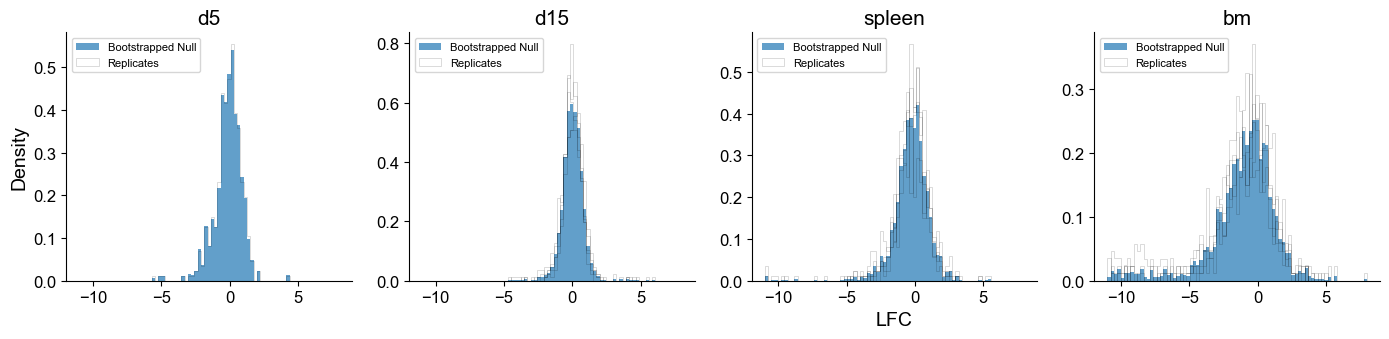

  d5 (n=1257): 23 Fisher hits, 23 Stouffer hits, 23 overlap (FDR<0.1)
    [Fisher] |LFC_avg_d5|>1: 21 depleted (<-1), 2 enriched (>1)
    [Fisher] |LFC_median_d5|>1: 21 depleted (<-1), 2 enriched (>1)
    [Fisher] |LFC_concordant_mean_d5|>1: 21 depleted (<-1), 2 enriched (>1)
    [Stouffer] |LFC_avg_d5|>1: 21 depleted (<-1), 2 enriched (>1)
    [Stouffer] |LFC_median_d5|>1: 21 depleted (<-1), 2 enriched (>1)
    [Stouffer] |LFC_concordant_mean_d5|>1: 21 depleted (<-1), 2 enriched (>1)
    [Overlap] |LFC_avg|>1: 21 depleted (<-1), 2 enriched (>1)
  d15 (n=1257): 109 Fisher hits, 164 Stouffer hits, 97 overlap (FDR<0.1)
    [Fisher] |LFC_avg_d15|>1: 46 depleted (<-1), 40 enriched (>1)
    [Fisher] |LFC_median_d15|>1: 38 depleted (<-1), 46 enriched (>1)
    [Fisher] |LFC_concordant_mean_d15|>1: 41 depleted (<-1), 41 enriched (>1)
    [Stouffer] |LFC_avg_d15|>1: 46 depleted (<-1), 38 enriched (>1)
    [Stouffer] |LFC_median_d15|>1: 40 depleted (<-1), 51 enriched (>1)
    [Stouffer] |LFC_con

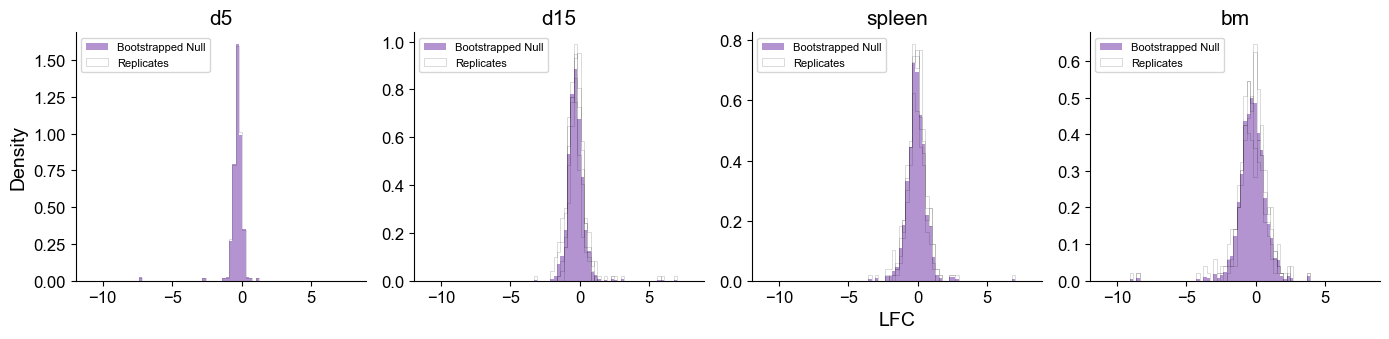

  d5 (n=376): 135 Fisher hits, 135 Stouffer hits, 135 overlap (FDR<0.1)
    [Fisher] |LFC_avg_d5|>1: 0 depleted (<-1), 28 enriched (>1)
    [Fisher] |LFC_median_d5|>1: 0 depleted (<-1), 28 enriched (>1)
    [Fisher] |LFC_concordant_mean_d5|>1: 0 depleted (<-1), 28 enriched (>1)
    [Stouffer] |LFC_avg_d5|>1: 0 depleted (<-1), 28 enriched (>1)
    [Stouffer] |LFC_median_d5|>1: 0 depleted (<-1), 28 enriched (>1)
    [Stouffer] |LFC_concordant_mean_d5|>1: 0 depleted (<-1), 28 enriched (>1)
    [Overlap] |LFC_avg|>1: 0 depleted (<-1), 28 enriched (>1)
  d15 (n=376): 150 Fisher hits, 153 Stouffer hits, 146 overlap (FDR<0.1)
    [Fisher] |LFC_avg_d15|>1: 1 depleted (<-1), 43 enriched (>1)
    [Fisher] |LFC_median_d15|>1: 1 depleted (<-1), 38 enriched (>1)
    [Fisher] |LFC_concordant_mean_d15|>1: 1 depleted (<-1), 42 enriched (>1)
    [Stouffer] |LFC_avg_d15|>1: 3 depleted (<-1), 42 enriched (>1)
    [Stouffer] |LFC_median_d15|>1: 2 depleted (<-1), 37 enriched (>1)
    [Stouffer] |LFC_concor

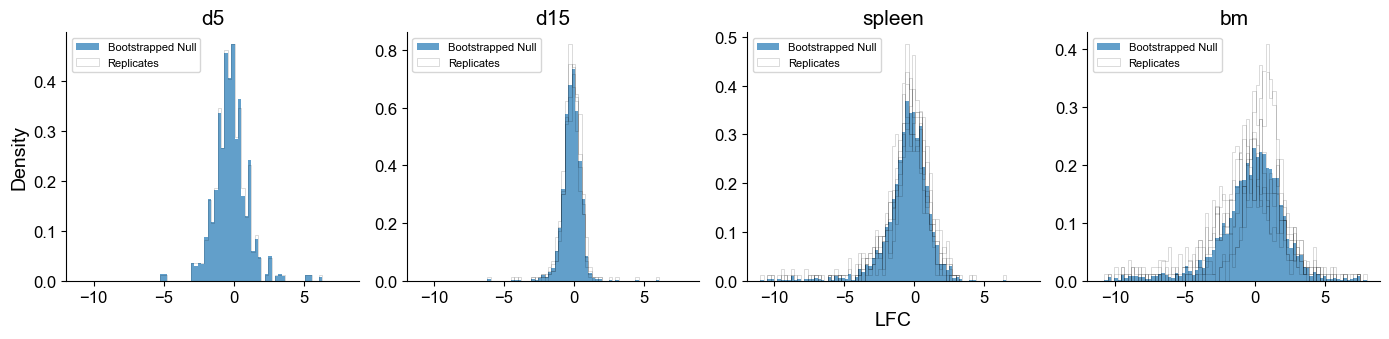

  d5 (n=1257): 12 Fisher hits, 12 Stouffer hits, 12 overlap (FDR<0.1)
    [Fisher] |LFC_avg_d5|>1: 5 depleted (<-1), 7 enriched (>1)
    [Fisher] |LFC_median_d5|>1: 5 depleted (<-1), 7 enriched (>1)
    [Fisher] |LFC_concordant_mean_d5|>1: 5 depleted (<-1), 7 enriched (>1)
    [Stouffer] |LFC_avg_d5|>1: 5 depleted (<-1), 7 enriched (>1)
    [Stouffer] |LFC_median_d5|>1: 5 depleted (<-1), 7 enriched (>1)
    [Stouffer] |LFC_concordant_mean_d5|>1: 5 depleted (<-1), 7 enriched (>1)
    [Overlap] |LFC_avg|>1: 5 depleted (<-1), 7 enriched (>1)
  d15 (n=1257): 135 Fisher hits, 196 Stouffer hits, 126 overlap (FDR<0.1)
    [Fisher] |LFC_avg_d15|>1: 15 depleted (<-1), 30 enriched (>1)
    [Fisher] |LFC_median_d15|>1: 13 depleted (<-1), 29 enriched (>1)
    [Fisher] |LFC_concordant_mean_d15|>1: 12 depleted (<-1), 31 enriched (>1)
    [Stouffer] |LFC_avg_d15|>1: 17 depleted (<-1), 28 enriched (>1)
    [Stouffer] |LFC_median_d15|>1: 17 depleted (<-1), 28 enriched (>1)
    [Stouffer] |LFC_concordan

In [94]:
# Run all screens!
results = {}
for screen_name, params in screens.items():
    combined_LFC_FDR, null_dict, controls = run_screen_pipeline(
        screen_name=screen_name, **params)
    results[screen_name] = {
        'LFC_FDR': combined_LFC_FDR,
        'null_dict': null_dict,
        'controls': controls,
    }
# Access results: results['ABE_OG']['LFC_FDR']

In [95]:
# Save combined LFC+FDR tables for all screens
output_dir = 'LFC-FDR'
os.makedirs(output_dir, exist_ok=True)

for screen_name, res in results.items():
    fp_out = os.path.join(output_dir, f'{screen_name}_LFC_FDR.csv')
    res['LFC_FDR'].to_csv(fp_out, index=False)
    print(f'{screen_name}: saved to {fp_out} ({res["LFC_FDR"].shape[0]} guides, {res["LFC_FDR"].shape[1]} columns)')

ABE_FC_EPO_T0: saved to LFC-FDR/ABE_FC_EPO_T0_LFC_FDR.csv (376 guides, 132 columns)
CBE_FC_EPO_T0: saved to LFC-FDR/CBE_FC_EPO_T0_LFC_FDR.csv (1257 guides, 137 columns)
ABE_FC_BC_T0: saved to LFC-FDR/ABE_FC_BC_T0_LFC_FDR.csv (376 guides, 132 columns)
CBE_FC_BC_T0: saved to LFC-FDR/CBE_FC_BC_T0_LFC_FDR.csv (1257 guides, 134 columns)
ABE_FC_EPO_TO_BC: saved to LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR.csv (376 guides, 132 columns)
CBE_FC_EPO_TO_BC: saved to LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR.csv (1257 guides, 137 columns)


In [83]:
list(res['LFC_FDR'].columns)

['gRNA_id',
 'Gene',
 'bonemarrow1',
 'bonemarrow2',
 'bonemarrow3',
 'bonemarrow4',
 'bonemarrow5',
 'bonemarrow6',
 'bonemarrow7',
 'bonemarrow8',
 'bonemarrow9',
 'bonemarrow10',
 'LFC_avg_bm',
 'LFC_median_bm',
 'LFC_concordant_mean_bm',
 'LFC_directional_bm',
 'z_score_avg_bm',
 'z_score_median_bm',
 'z_score_concordant_mean_bm',
 'Input_median',
 'd15_rep1',
 'd15_rep2',
 'd15_rep3',
 'LFC_avg_d15',
 'LFC_median_d15',
 'LFC_concordant_mean_d15',
 'LFC_directional_d15',
 'z_score_avg_d15',
 'z_score_median_d15',
 'z_score_concordant_mean_d15',
 'd5_rep1',
 'd5_rep2',
 'd5_rep3',
 'LFC_avg_d5',
 'LFC_median_d5',
 'LFC_concordant_mean_d5',
 'LFC_directional_d5',
 'z_score_avg_d5',
 'z_score_median_d5',
 'z_score_concordant_mean_d5',
 'plasmidlib',
 'LFC_avg_lib',
 'LFC_median_lib',
 'LFC_concordant_mean_lib',
 'LFC_directional_lib',
 'z_score_avg_lib',
 'z_score_median_lib',
 'z_score_concordant_mean_lib',
 'meninges1',
 'meninges2',
 'meninges3',
 'meninges4',
 'meninges5',
 'menin

---
## Excluded Samples — Complete List

All samples removed from LFC-FDR analysis due to abnormal 90/10 skew ratio (identified by QC in `global_analysis.ipynb`).

### ABE OG
No samples excluded.

### CBE OG
| Sample | Tissue | Reason |
|--------|--------|--------|
| `spleen10` | Spleen | Abnormal skewing |

### ABE Focused (EPO and BC)
ABE EPO and ABE BC count tables are independent experiments but share the same per-tissue sample exclusions.

| Sample | Tissue | Reason |
|--------|--------|--------|
| `bm2` | Bone marrow | Abnormal skewing |
| `spleen2` | Spleen | Abnormal skewing |

### CBE Focused EPO
| Sample | Tissue | Reason |
|--------|--------|--------|
| `bm2` | Bone marrow | Abnormal skewing |
| `bm5` | Bone marrow | Abnormal skewing |
| `bm8` | Bone marrow | Abnormal skewing |
| `spleen2` | Spleen | Abnormal skewing |
| `spleen5` | Spleen | Abnormal skewing |
| `spleen8` | Spleen | Abnormal skewing |
| `d15-rep2` | D15 in vitro | Abnormal skewing |

### CBE Focused BC (null screen)
| Sample | Tissue | Reason |
|--------|--------|--------|
| `bm1` | Bone marrow | Abnormal skewing |
| `bm2` | Bone marrow | Abnormal skewing |
| `bm6` | Bone marrow | Abnormal skewing |
| `bm8` | Bone marrow | Abnormal skewing |
| `bm10` | Bone marrow | Abnormal skewing |
| `spleen1` | Spleen | Abnormal skewing |
| `spleen2` | Spleen | Abnormal skewing |
| `spleen6` | Spleen | Abnormal skewing |
| `spleen8` | Spleen | Abnormal skewing |
| `spleen10` | Spleen | Abnormal skewing |
